# Agent Retrieval Experiment Analysis
Configure the batch name below and run all cells.

In [1]:
BATCH_NAME = "full-sweep__20260408T130426"
WORKSPACE_DIR = "../workspace"

In [2]:
from pathlib import Path
from agent_retrieval.analysis.loader import load_batch_results
df = load_batch_results(BATCH_NAME, Path(WORKSPACE_DIR))
print(f"Loaded {len(df)} verdicts across {df['experiment_id'].nunique()} parametrisations")
df.head()

Loaded 548 verdicts across 173 parametrisations


,experiment_id,run_id,batch_name,weighted_score,total_context_tokens,total_turns,duration_seconds,content_profile,corpus_token_count,discriminability,...,score_chain_understanding,score_synonym_understanding,score_integration,score_synthesis,score_inference,score_Finds all 16 needles embedded in context,score_Understands connections between scattered information,score_Constructs accurate timeline across all cases,score_Identifies characters through contextual clues,score_Connects institutional/moral failures to outcomes
0,multi_chain__noir_fiction__160k__easy__context...,053763251176,full-sweep__20260408T130426,0.0600,55797,3,0.0,noir_fiction,160000,easy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,multi_chain__noir_fiction__160k__easy__context...,49898c06edb2,full-sweep__20260408T130426,0.0000,331023,17,0.0,noir_fiction,160000,easy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,multi_chain__noir_fiction__160k__easy__context...,9ac462de12aa,full-sweep__20260408T130426,0.0933,91311,5,0.0,noir_fiction,160000,easy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,multi_chain__noir_fiction__160k__easy__context...,c3d7fcb54b31,full-sweep__20260408T130426,1.0000,130628,8,0.0,noir_fiction,160000,easy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,multi_chain__noir_fiction__160k__easy__context...,c9657ef39a9b,full-sweep__20260408T130426,0.0000,71979,4,0.0,noir_fiction,160000,easy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Accuracy by Experiment Type

In [3]:
from agent_retrieval.analysis.tables import accuracy_by_type
accuracy_by_type(df)

,experiment_type,mean,std,count
0,multi_chain,0.495259,0.447607,319
1,multi_reasoning,0.224684,0.327273,114
2,single_needle,0.876523,0.280716,115


## Accuracy by Parameter

In [4]:
from agent_retrieval.analysis.tables import accuracy_by_param
accuracy_by_param(df, "corpus_token_count")

,experiment_type,corpus_token_count,mean,std,count
0,multi_chain,20000,0.490797,0.450195,70
1,multi_chain,40000,0.440267,0.434496,54
2,multi_chain,160000,0.594174,0.449428,140
3,multi_chain,800000,0.303149,0.386857,55
4,multi_reasoning,20000,0.299100,0.356819,51
5,multi_reasoning,40000,0.068522,0.205567,9
6,multi_reasoning,160000,0.180430,0.300673,54
7,single_needle,20000,0.891200,0.245289,36
8,single_needle,40000,0.967336,0.054954,25
9,single_needle,160000,0.748153,0.407021,36


## Tool Usage

In [5]:
from agent_retrieval.analysis.tables import tool_usage_by_type
tool_usage_by_type(df)

,experiment_type,Agent_mean,Agent_std,Glob_mean,Glob_std,Read_mean,Read_std,Bash_mean,Bash_std,Grep_mean,Grep_std,Agent,Glob,Read,Bash,Grep
0,multi_chain,1.167630,0.389832,1.567742,0.702679,3.152174,2.367364,7.901786,8.939194,3.929078,4.336960,1.167630,1.567742,3.152174,7.901786,3.929078
1,multi_reasoning,1.178947,0.385342,1.294118,0.587868,5.296296,3.998219,5.500000,4.847680,3.368421,2.476793,1.178947,1.294118,5.296296,5.500000,3.368421
2,single_needle,1.045455,0.213201,1.235294,0.752447,1.882353,1.754038,5.684211,7.810624,2.583333,2.448057,1.045455,1.235294,1.882353,5.684211,2.583333


## Figure 1: Accuracy vs Corpus Size

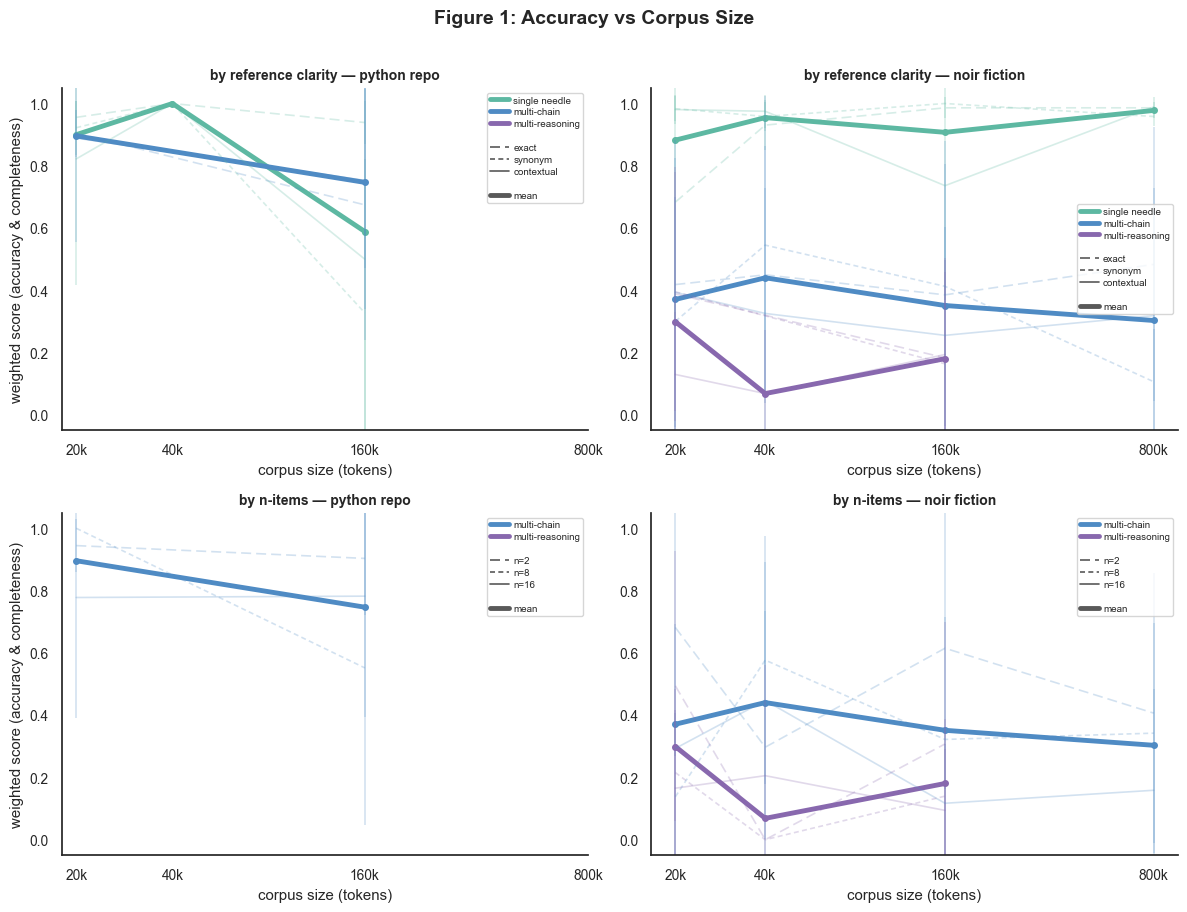

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="white", font_scale=0.9)

EXP_ORDER = ["single_needle", "multi_chain", "multi_reasoning"]
EXP_LABELS = {"single_needle": "single needle", "multi_chain": "multi-chain", "multi_reasoning": "multi-reasoning"}
PROFILES = ["python_repo", "noir_fiction"]
PROFILE_LABELS = {"noir_fiction": "noir fiction", "python_repo": "python repo"}
CLARITY_ORDER = ["exact", "synonym", "contextual"]
N_ITEMS_ORDER = [2, 8, 16]

# Cohesive teal → blue → purple (light → dark ≈ easy → hard task)
EXP_PALETTE = {"single_needle": "#5DB8A2", "multi_chain": "#4F8BC4", "multi_reasoning": "#8868AE"}

# Warm earth/amber palette for tools (distinct from cool experiment colours)
TOOL_PALETTE = ["#D4956A", "#C47858", "#B8A07A", "#9C7E68", "#BCA890"]

CLARITY_DASHES = {"exact": (6, 3), "synonym": (3, 2), "contextual": ""}
NITEMS_DASHES = {2: (6, 3), 8: (3, 2), 16: ""}

DETAIL_ALPHA = 0.25
MEAN_ALPHA = 1.0
MEAN_LW = 3.5
DETAIL_LW = 1.2

CORPUS_SIZES = [20_000, 40_000, 160_000, 800_000]
CORPUS_LABELS = ["20k", "40k", "160k", "800k"]

def set_corpus_xticks(ax):
    ax.set_xscale("log")
    ax.set_xticks(CORPUS_SIZES)
    ax.set_xticklabels(CORPUS_LABELS)
    ax.xaxis.set_minor_locator(mticker.NullLocator())

def add_legend(ax, mode="clarity"):
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER if mode == "clarity" or e in ["multi_chain", "multi_reasoning"]
    ]
    spacer = mlines.Line2D([], [], linestyle="none", label="")
    if mode == "clarity":
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          dashes=CLARITY_DASHES[c] if CLARITY_DASHES[c] else (None, None),
                          linestyle="--" if CLARITY_DASHES[c] else "-", label=c)
            for c in CLARITY_ORDER
        ]
    else:
        series_handles = [
            mlines.Line2D([], [], color="0.35", linewidth=1.2,
                          dashes=NITEMS_DASHES[n] if NITEMS_DASHES[n] else (None, None),
                          linestyle="--" if NITEMS_DASHES[n] else "-", label=f"n={n}")
            for n in N_ITEMS_ORDER
        ]
    mean_handle = mlines.Line2D([], [], color="0.35", linewidth=3.5, linestyle="-", label="mean")
    all_handles = type_handles + [spacer] + series_handles + [spacer, mean_handle]
    ax.legend(handles=all_handles, fontsize=7, loc="best", ncol=1,
              handletextpad=0.4, borderpad=0.3, labelspacing=0.3)

def plot_series(ax, df, y_col, exp_types, mode="clarity"):
    items = CLARITY_ORDER if mode == "clarity" else N_ITEMS_ORDER
    dashes = CLARITY_DASHES if mode == "clarity" else NITEMS_DASHES
    group_col = "reference_clarity" if mode == "clarity" else "n_items"

    for exp_type in exp_types:
        color = EXP_PALETTE[exp_type]
        sub_all = df[df["experiment_type"] == exp_type]
        if mode == "nitems":
            sub_all = sub_all.dropna(subset=["n_items"])
        if sub_all.empty:
            continue

        for item in items:
            isub = sub_all[sub_all[group_col] == item]
            if isub.empty:
                continue
            stats = isub.groupby("corpus_token_count")[y_col].agg(["mean", "std"]).reset_index()
            dash = dashes[item]
            ax.errorbar(
                stats["corpus_token_count"], stats["mean"], yerr=stats["std"].fillna(0),
                color=color, linewidth=DETAIL_LW, capsize=0, markersize=0,
                linestyle="--" if dash else "-", dashes=dash if dash else None,
                alpha=DETAIL_ALPHA,
            )

        mean_stats = sub_all.groupby("corpus_token_count")[y_col].agg(["mean"]).reset_index()
        ax.plot(
            mean_stats["corpus_token_count"], mean_stats["mean"],
            color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
        )

# --- Figure 1: Accuracy vs Corpus Size (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for col_idx, profile in enumerate(PROFILES):
    ax = axes[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", EXP_ORDER, mode="clarity")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score (accuracy & completeness)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

for col_idx, profile in enumerate(PROFILES):
    ax = axes[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "weighted_score", ["multi_chain", "multi_reasoning"], mode="nitems")
    ax.set_ylim(-0.05, 1.05)
    set_corpus_xticks(ax)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("weighted score (accuracy & completeness)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig.suptitle("Figure 1: Accuracy vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## Figure 2: Token Consumption vs Corpus Size (normalised)

Y-axis shows total input context tokens (input + cache creation + cache read) as a percentage of corpus size. This does **not** include output tokens (model responses, thinking, tool call arguments).

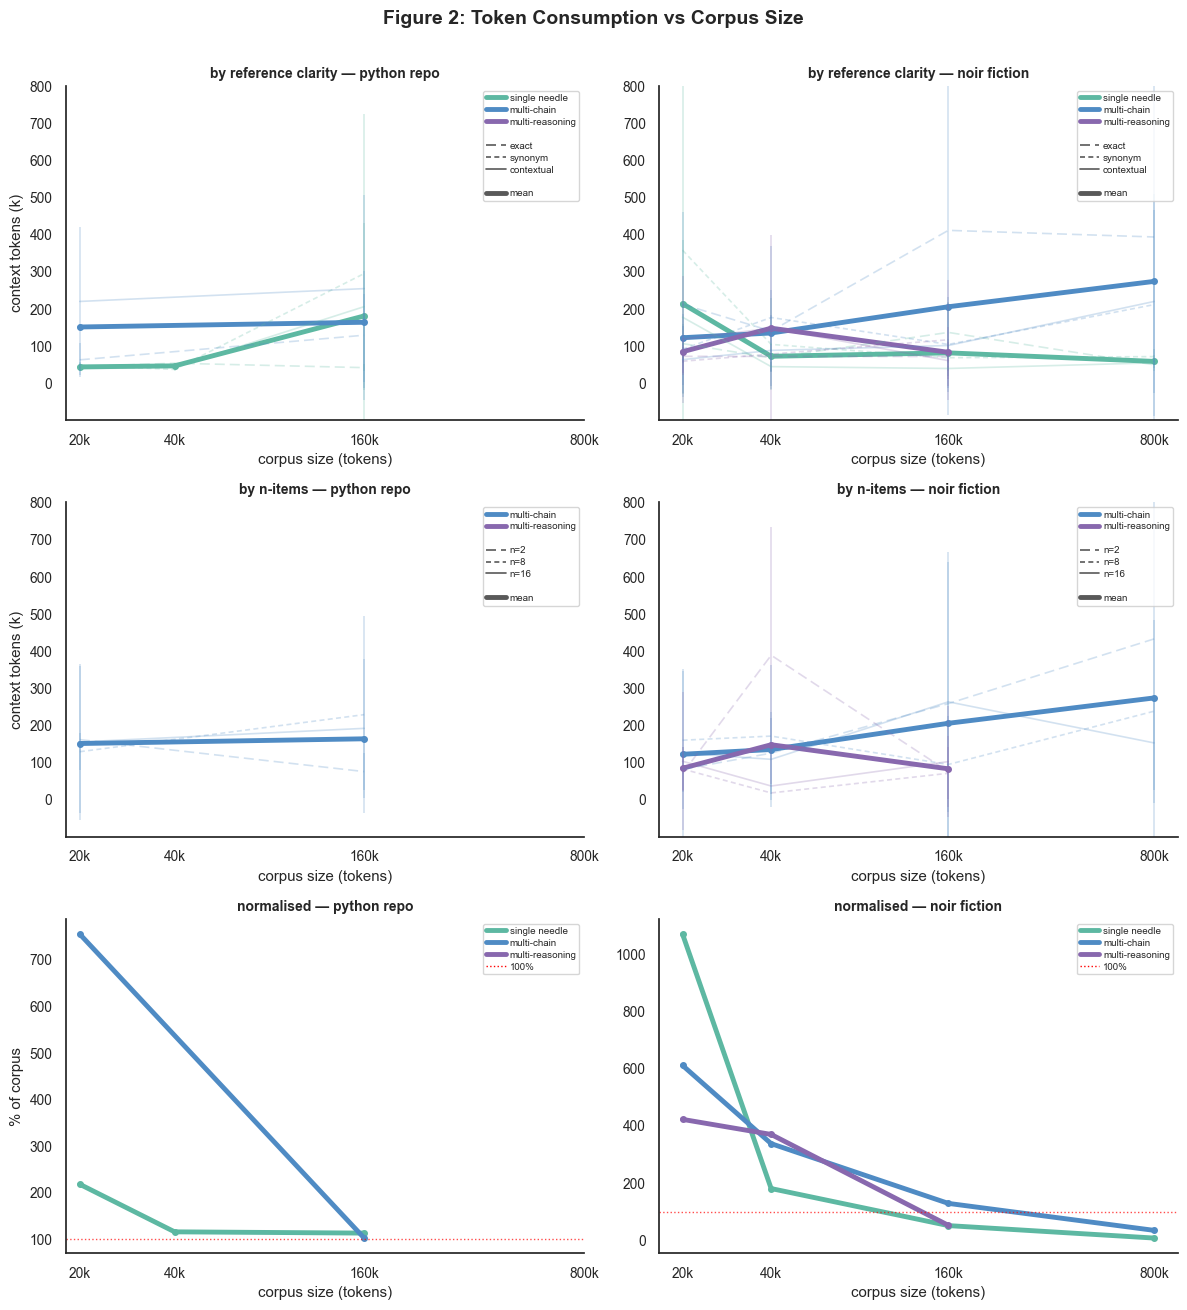

In [7]:
df["token_pct_of_corpus"] = df["total_context_tokens"] / df["corpus_token_count"] * 100
df["context_tokens_k"] = df["total_context_tokens"] / 1000

TOKEN_YTICKS = [0, 100, 200, 300, 400, 500, 600, 700, 800]

fig2, axes2 = plt.subplots(3, 2, figsize=(12, 13))

for col_idx, profile in enumerate(PROFILES):
    ax = axes2[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "context_tokens_k", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_ylim(-100, 800)
    ax.set_yticks(TOKEN_YTICKS)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("context tokens (k)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

for col_idx, profile in enumerate(PROFILES):
    ax = axes2[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "context_tokens_k", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_ylim(-100, 800)
    ax.set_yticks(TOKEN_YTICKS)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("context tokens (k)")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

for col_idx, profile in enumerate(PROFILES):
    ax = axes2[2, col_idx]
    sub = df[df["content_profile"] == profile]
    for exp_type in EXP_ORDER:
        color = EXP_PALETTE[exp_type]
        esub = sub[sub["experiment_type"] == exp_type]
        if esub.empty:
            continue
        stats = esub.groupby("corpus_token_count")["token_pct_of_corpus"].agg(["mean"]).reset_index()
        ax.plot(
            stats["corpus_token_count"], stats["mean"],
            color=color, linewidth=MEAN_LW, alpha=MEAN_ALPHA, marker="o", markersize=4,
        )
    ax.axhline(100, color="red", linestyle=":", linewidth=1, alpha=0.7)
    set_corpus_xticks(ax)
    ax.set_title(f"normalised — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("% of corpus")
    ax.set_xlabel("corpus size (tokens)")
    type_handles = [
        mlines.Line2D([], [], color=EXP_PALETTE[e], linewidth=3.5, linestyle="-", label=EXP_LABELS[e])
        for e in EXP_ORDER
    ]
    type_handles.append(mlines.Line2D([], [], color="red", linestyle=":", linewidth=1, label="100%"))
    ax.legend(handles=type_handles, fontsize=7, loc="best", handletextpad=0.4, borderpad=0.3, labelspacing=0.3)
    sns.despine(ax=ax)

fig2.suptitle("Figure 2: Token Consumption vs Corpus Size", fontsize=14, fontweight="bold", y=1.005)
fig2.tight_layout()
plt.show()

## Figure 3: Tool Calls vs Corpus Size

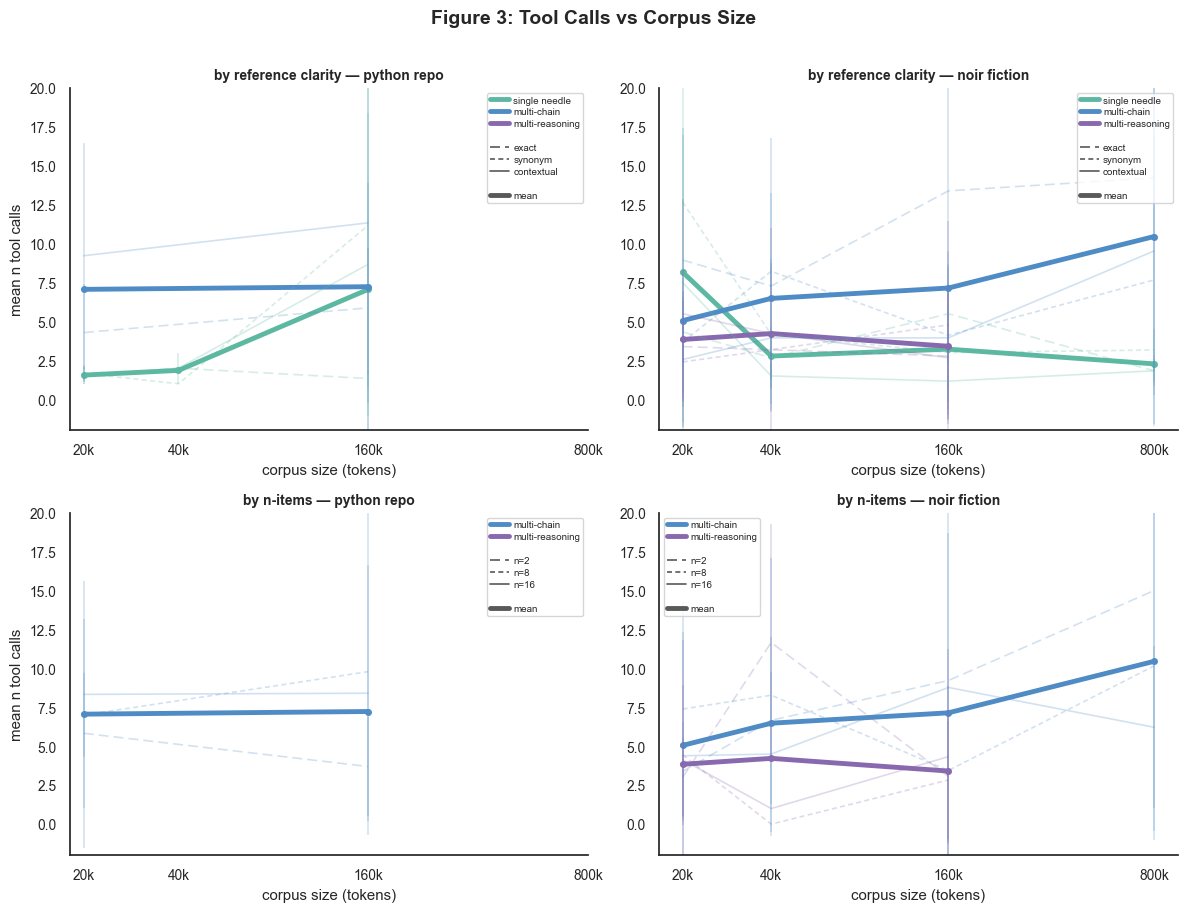

In [8]:
tool_cols = [c for c in df.columns if c.startswith("tool_")]
df["total_tool_calls"] = df[tool_cols].sum(axis=1)

max_tool_mean = df.groupby(["experiment_type", "corpus_token_count"])["total_tool_calls"].mean().max()
tool_ylim = (-2, int(np.ceil(max_tool_mean / 5) * 5) + 5)

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 9))

for col_idx, profile in enumerate(PROFILES):
    ax = axes3[0, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", EXP_ORDER, mode="clarity")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by reference clarity — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="clarity")
    sns.despine(ax=ax)

for col_idx, profile in enumerate(PROFILES):
    ax = axes3[1, col_idx]
    sub = df[df["content_profile"] == profile]
    plot_series(ax, sub, "total_tool_calls", ["multi_chain", "multi_reasoning"], mode="nitems")
    set_corpus_xticks(ax)
    ax.set_ylim(tool_ylim)
    ax.set_title(f"by n-items — {PROFILE_LABELS[profile]}", fontsize=10, fontweight="bold")
    if col_idx == 0:
        ax.set_ylabel("mean n tool calls")
    ax.set_xlabel("corpus size (tokens)")
    add_legend(ax, mode="nitems")
    sns.despine(ax=ax)

fig3.suptitle("Figure 3: Tool Calls vs Corpus Size", fontsize=14, fontweight="bold", y=1.01)
fig3.tight_layout()
plt.show()

## Figure 4: Tool Breakdown by Experiment Type

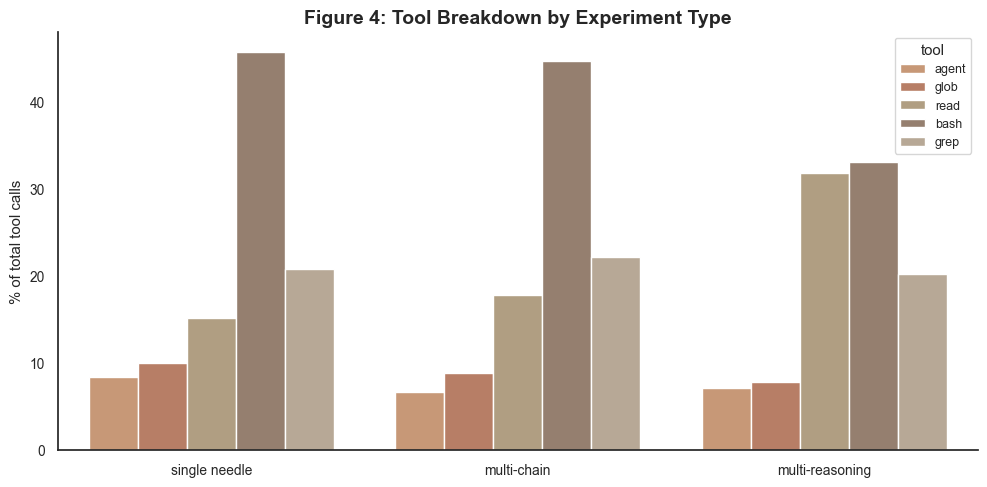

In [9]:
import pandas as pd

tool_cols = [c for c in df.columns if c.startswith("tool_")]
tool_names = [c.replace("tool_", "").lower() for c in tool_cols]

tool_data = []
for exp_type in EXP_ORDER:
    sub = df[df["experiment_type"] == exp_type]
    means = {tn: sub[tc].mean() for tc, tn in zip(tool_cols, tool_names) if not np.isnan(sub[tc].mean())}
    total = sum(means.values())
    if total > 0:
        for tn, mean_val in means.items():
            tool_data.append({
                "experiment type": EXP_LABELS[exp_type],
                "tool": tn,
                "% of total calls": mean_val / total * 100,
            })

tool_df = pd.DataFrame(tool_data)

fig4, ax4 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tool_df, x="experiment type", y="% of total calls", hue="tool",
    palette=TOOL_PALETTE, ax=ax4,
)
ax4.set_title("Figure 4: Tool Breakdown by Experiment Type", fontsize=14, fontweight="bold")
ax4.legend(title="tool", fontsize=9)
ax4.set_xlabel("")
ax4.set_ylabel("% of total tool calls")
sns.despine(ax=ax4)
fig4.tight_layout()
plt.show()

## V2 Parameter Breakdowns

In [10]:
from agent_retrieval.analysis.tables import accuracy_by_param

print("=== By Discriminability ===")
display(accuracy_by_param(df, "discriminability"))

print("\n=== By Reference Clarity ===")
display(accuracy_by_param(df, "reference_clarity"))

print("\n=== By Content Profile ===")
display(accuracy_by_param(df, "content_profile"))

print("\n=== By N Items ===")
display(accuracy_by_param(df, "n_items"))

=== By Discriminability ===


,experiment_type,discriminability,mean,std,count
0,multi_chain,easy,0.546517,0.451728,179
1,multi_chain,hard,0.429722,0.435131,140
2,multi_reasoning,easy,0.235140,0.330736,60
3,multi_reasoning,hard,0.213067,0.326084,54
4,single_needle,easy,0.928689,0.226369,61
5,single_needle,hard,0.817594,0.323753,54



=== By Reference Clarity ===


,experiment_type,reference_clarity,mean,std,count
0,multi_chain,contextual,0.476464,0.449500,109
1,multi_chain,exact,0.533204,0.438152,111
2,multi_chain,synonym,0.473409,0.457673,99
3,multi_reasoning,contextual,0.143211,0.250861,45
4,multi_reasoning,exact,0.285775,0.372773,36
5,multi_reasoning,synonym,0.269139,0.352328,33
6,single_needle,contextual,0.846582,0.332964,39
7,single_needle,exact,0.920087,0.185047,39
8,single_needle,synonym,0.862162,0.305171,37



=== By Content Profile ===


,experiment_type,content_profile,mean,std,count
0,multi_chain,noir_fiction,0.366072,0.415380,217
1,multi_chain,python_repo,0.770099,0.386875,102
2,multi_reasoning,noir_fiction,0.224684,0.327273,114
3,single_needle,noir_fiction,0.930557,0.180158,72
4,single_needle,python_repo,0.786047,0.381622,43



=== By N Items ===


,experiment_type,n_items,mean,std,count
0,multi_chain,2.0,0.636704,0.430561,108
1,multi_chain,8.0,0.426005,0.436599,106
2,multi_chain,16.0,0.419688,0.444977,105
3,multi_reasoning,2.0,0.369915,0.415627,39
4,multi_reasoning,8.0,0.164005,0.252316,39
5,multi_reasoning,16.0,0.133086,0.229993,36


## Custom Analysis
Use the `results` DataFrame for ad-hoc exploration.

In [11]:
df.describe()

,weighted_score,total_context_tokens,total_turns,duration_seconds,corpus_token_count,n_items,tool_Agent,tool_Glob,score_correctness,score_completeness,...,score_synthesis,score_inference,score_Finds all 16 needles embedded in context,score_Understands connections between scattered information,score_Constructs accurate timeline across all cases,score_Identifies characters through contextual clues,score_Connects institutional/moral failures to outcomes,token_pct_of_corpus,context_tokens_k,total_tool_calls
count,548.000000,5.480000e+02,548.000000,548.0,548.000000,433.000000,290.000000,189.000000,543.000000,545.000000,...,6.000000,3.000000,3.0,3.0,3.0,3.0,3.0,548.000000,548.000000,548.000000
mean,0.518981,1.434678e+05,6.810219,0.0,185875.912409,8.568129,1.162069,1.513228,0.541639,0.484385,...,0.250000,0.226667,0.0,0.0,0.0,0.0,0.0,253.183880,143.467816,5.841241
std,0.447526,2.217314e+05,7.881464,0.0,248866.826946,5.728470,0.378408,0.704155,0.462666,0.432391,...,0.279285,0.064291,0.0,0.0,0.0,0.0,0.0,536.912575,221.731393,7.875307
min,0.000000,1.788600e+04,1.000000,0.0,20000.000000,2.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.180000,0.0,0.0,0.0,0.0,0.0,4.478750,17.886000,0.000000
25%,0.000000,3.669900e+04,2.000000,0.0,20000.000000,2.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.190000,0.0,0.0,0.0,0.0,0.0,23.998250,36.699000,1.000000
50%,0.643900,5.482450e+04,3.000000,0.0,160000.000000,8.000000,1.000000,1.000000,0.750000,0.500000,...,0.225000,0.200000,0.0,0.0,0.0,0.0,0.0,92.086250,54.824500,2.000000
75%,1.000000,1.411268e+05,9.000000,0.0,160000.000000,16.000000,1.000000,2.000000,1.000000,1.000000,...,0.450000,0.250000,0.0,0.0,0.0,0.0,0.0,260.841875,141.126750,8.000000
max,1.000000,2.028288e+06,56.000000,0.0,800000.000000,16.000000,3.000000,4.000000,1.000000,1.000000,...,0.600000,0.300000,0.0,0.0,0.0,0.0,0.0,6885.210000,2028.288000,55.000000
